# Step 3: Model Training & Evaluation

**Goal:** Train a Machine Learning model to predict the `Scholarship_Priority_Score` accurately.

**Strategy:**
1.  **Load** the processed data (from Step 1).
2.  **Experiment A (Linear Regression):** Establish a baseline.
3.  **Experiment B (Ridge Regression):** Apply regularization to handle correlated features (like JEE vs. CET scores).
4.  **Select & Save:** Pick the best performing model and bundle it with the preprocessor for the Dashboard.

In [6]:
# 1. Setup & Load Processed Data

import numpy as np
import pandas as pd
import joblib
import os
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define Paths
BASE_DIR = os.path.dirname(os.getcwd())
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'models')

print(" Loading Processed Data...")

 Loading Processed Data...


In [3]:
X_train = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")

   X_train: (800, 11)
   y_train: (800,)


## 2. Experiment A: Standard Linear Regression

**The Baseline Approach:**
We start with the simplest model. Linear Regression tries to draw a straight line that best fits the data points.

* **Pros:** Simple, easy to interpret.
* **Cons:** Can be unstable if features are highly correlated (e.g., if a student has high JEE, they likely have high CET too).

In [ ]:
# 2.Standard Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Evaluate
y_pred_lr = model_lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"   R² Score: {r2_lr:.4f}")
print(f"   MAE:      {mae_lr:.2f}")

   R² Score: 0.8529
   MAE:      2.75


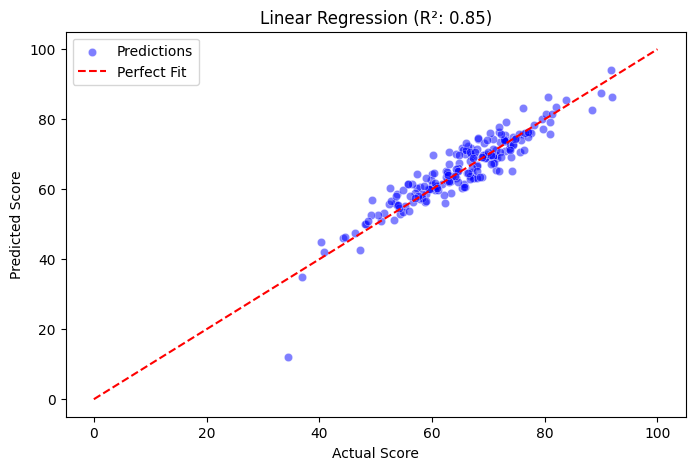

In [9]:
# Visual Check
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.5, color='blue', label='Predictions')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Fit')
plt.title(f"Linear Regression (R²: {r2_lr:.2f})")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.legend()
plt.show()

## 3. Experiment B: Ridge Regression (L2 Regularization)

**Why change models?**
In our EDA (Step 2), we saw that `JEE_Percentile` and `Mh_CET_Percentile` are highly correlated. Standard Linear Regression gets confused by this "Multicollinearity," sometimes assigning extreme positive weights to one exam and negative to another.

**The Solution:**
Ridge Regression adds a small penalty (L2) to the size of the coefficients. This forces the model to spread the weight more evenly across correlated features, making it:
1.  **More Stable:** Less sensitive to small changes in input.
2.  **More Robust:** Better generalization to new students.

In [ ]:

# 3. Ridge Regression

model_ridge = Ridge(alpha=1.0) # alpha=1.0 is the standard strength
model_ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [11]:
# Evaluate
y_pred_ridge = model_ridge.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(f"   R² Score: {r2_ridge:.4f}")
print(f"   MAE:      {mae_ridge:.2f}")

   R² Score: 0.8535
   MAE:      2.75


In [13]:
print("\n Comparison:")
print(f"   Linear R²: {r2_lr:.4f} vs Ridge R²: {r2_ridge:.4f}")
if r2_ridge >= r2_lr:
    print(" Ridge performed equal to or better than Linear (Preferred).")
else:
    print(" Linear performed slightly better (Data might be very simple).")


 Comparison:
   Linear R²: 0.8529 vs Ridge R²: 0.8535
 Ridge performed equal to or better than Linear (Preferred).


## 4. Deployment: Bundling the Final Model

**The "Pipeline" Concept:**
We cannot just save the model. If we do, the App won't know how to scale the income or encode the caste.

**We create a unified Pipeline:**
`Raw Data` -> `Preprocessor` (Scale/Encode) -> `Ridge Model` -> `Prediction`

We save this entire chain as `scholarship_model.pkl`. This ensures that the Streamlit App works exactly like our training notebook.

In [15]:

# 4. Save Final Production Pipeline

print("\n Bundling the Best Model...")

# 1. Load the Preprocessor (The 'Brain' from Step 1)
preprocessor_path = os.path.join(ARTIFACTS_DIR, 'preprocessor.pkl')
preprocessor = joblib.load(preprocessor_path)


 Bundling the Best Model...


In [16]:
# 2. Bundle Preprocessor + Ridge Model
# This creates a single file that takes Raw Input -> Prediction
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', model_ridge)
])

In [17]:
# 3. Save
save_path = os.path.join(ARTIFACTS_DIR, 'scholarship_model.pkl')
joblib.dump(final_pipeline, save_path)

print(f"SUCCESS: Final Pipeline saved to {save_path}")
print("   Ready for Dashboard deployment.")

SUCCESS: Final Pipeline saved to c:\Users\rudra\OneDrive\Documents\Hackathon 3 Og\models\scholarship_model.pkl
   Ready for Dashboard deployment.
